# Mind2Web Debug Evaluation

Debug notebook for testing Magma fine-tuned checkpoints on Mind2Web validation set.

Loads the model with LoRA adapters, runs inference on val samples using the same prompt format as training, and compares against `{"ACTION", "MARK", "VALUE"}` ground truth.

## 1. Setup and Imports

In [11]:
# Install required dependencies (run this on Colab or if packages are missing)
# Magma requires transformers 4.49.0 - 4.51.x (NOT 5.x which has breaking changes)

%pip install open_clip_torch peft bitsandbytes accelerate -q
# %pip install "transformers>=4.49.0,<5.0.0" -q  # Pin to 4.x to avoid breaking changes
%pip install git+https://github.com/jwyang/transformers.git@dev/jwyang-v4.48.2

Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/jwyang/transformers.git (to revision dev/jwyang-v4.48.2) to /tmp/pip-req-build-j4uye9r3
  Running command git clone --filter=blob:none --quiet https://github.com/jwyang/transformers.git /tmp/pip-req-build-j4uye9r3
  Running command git checkout -b dev/jwyang-v4.48.2 --track origin/dev/jwyang-v4.48.2
  Switched to a new branch 'dev/jwyang-v4.48.2'
  Branch 'dev/jwyang-v4.48.2' set up to track remote branch 'dev/jwyang-v4.48.2' from 'origin'.
  Resolved https://github.com/jwyang/transformers.git to commit 1708d3ca3608b3c229d7ce6f0351e652436d7d33
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [12]:
# Check transformers version after install
import transformers
print(f"Transformers version: {transformers.__version__}")

from packaging import version
tf_version = version.parse(transformers.__version__)

if tf_version < version.parse("4.49.0"):
    print("Warning: Transformers version is too old! Magma requires >=4.49.0")
    print("Please restart the kernel for the new transformers version to take effect!")
elif tf_version >= version.parse("5.0.0"):
    print("Warning: Transformers 5.x detected - this has breaking changes with Magma!")
    print("Please run: %pip install 'transformers>=4.49.0,<5.0.0' -q")
    print("Then restart the kernel!")
else:
    print("Transformers version is compatible with Magma")

Transformers version: 4.48.2
Please restart the kernel for the new transformers version to take effect!


In [13]:
import os
import sys
import json
import re
import torch
from PIL import Image
from transformers import AutoModelForCausalLM, AutoProcessor
from IPython.display import display

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4070 Ti SUPER


In [14]:
# Patch for PyTorch 2.10+ compatibility with Magma model
# The model uses sum() on boolean tensors which requires explicit conversion in newer PyTorch

if not hasattr(torch, '_original_sum_backup'):
    torch._original_sum_backup = torch.sum

def _patched_sum(input, *args, **kwargs):
    """Patched sum that converts bool tensors to long before summing with dim."""
    if isinstance(input, bool):
        input = torch.tensor(input, dtype=torch.long)
    elif isinstance(input, torch.Tensor) and input.dtype == torch.bool and (len(args) > 0 or 'dim' in kwargs):
        input = input.long()
    return torch._original_sum_backup(input, *args, **kwargs)

torch.sum = _patched_sum
print("Applied PyTorch sum() patch for boolean tensor compatibility")

Applied PyTorch sum() patch for boolean tensor compatibility


## 2. Configuration

Base model: microsoft/Magma-8B
Image size: (1280, 832)


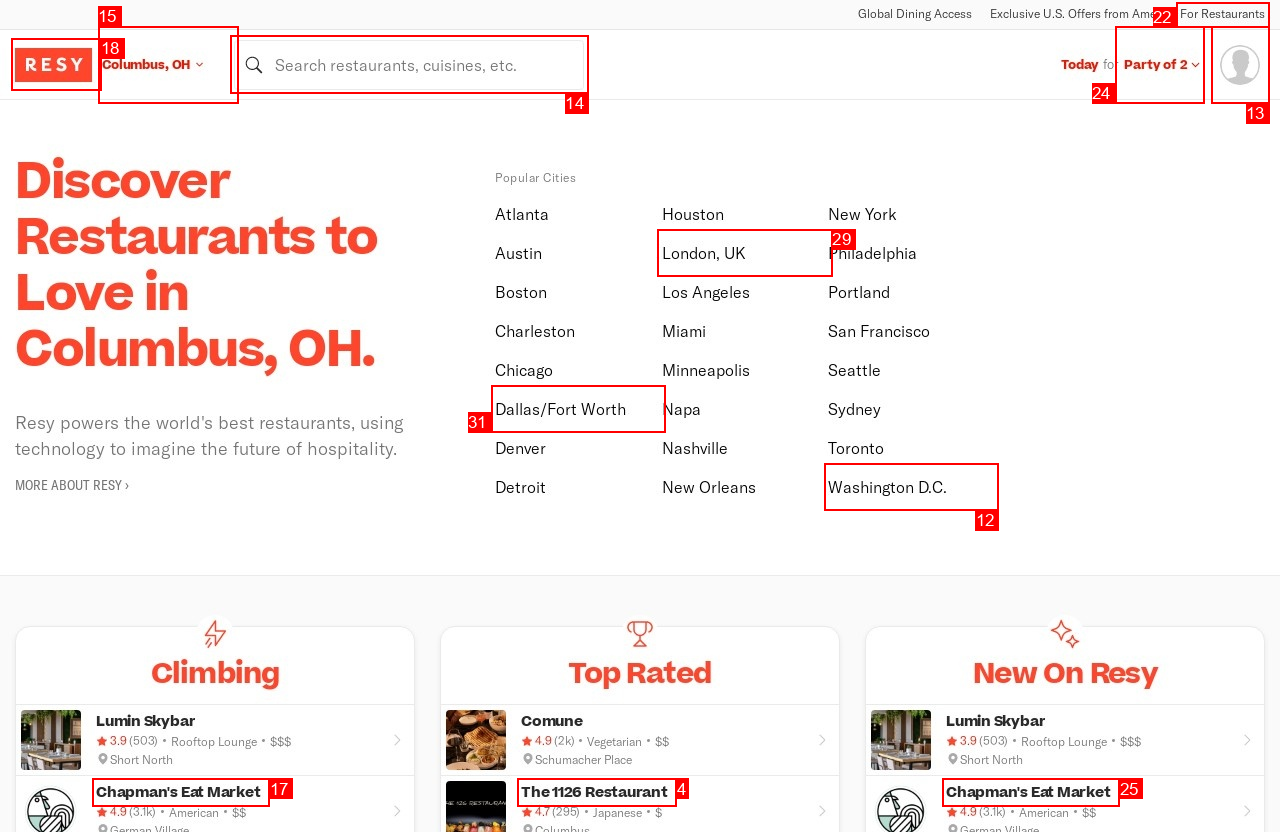

In [15]:
# Base model name
BASE_MODEL = "microsoft/Magma-8B"

# # Dataset config
# HF_DATASET_NAME = "MagmaAI/Magma-Mind2Web-SoM"
# HF_DATASET_SPLIT = "train"

# # Which sample index to debug
# SAMPLE_INDEX = 0
IMAGE_PATH = "/home/thaole/thao_le/Magma/datasets/mind2web/images/mind2web_007019.png"
INSTRUCTION = "Imagine that you are imitating humans doing web navigation for a task step by step. At each stage, you can see the webpage like humans by a screenshot and know the previous actions before the current step decided by yourself through recorded history. You need to decide on the following action to take. You can click an element with the mouse, select an option, or type text with the keyboard. The output format should be a dictionary like: \n\"{\"ACTION\": \"CLICK\" or \"TYPE\" or \"SELECT\", \"MARK\": a numeric id, e.g., 5, \"VALUE\": a string value for the action if applicable, otherwise None}\".\nYou are asked to complete the following task: Find a Thai restaurant and get notified when they have an open table between 5 to 7 PM. For your convinience, I have labeled the candidates with numeric marks and bounding boxes on the screenshot. What is the next action you would take?\n"
GROUND_TRUTH_BBOX = "{\"ACTION\": \"TYPE\", \"MARK\": 14, \"VALUE\": \"thai\"}" 

image = Image.open(IMAGE_PATH).convert('RGB')
print(f"Base model: {BASE_MODEL}")
print(f"Image size: {image.size}")
display(image)
# print(f"Dataset: {HF_DATASET_NAME} (split: {HF_DATASET_SPLIT})")
# print(f"Sample index: {SAMPLE_INDEX}")


## 3. Load Dataset

In [16]:
# from datasets import load_dataset

# print(f"Loading dataset: {HF_DATASET_NAME} (split: {HF_DATASET_SPLIT})")
# dataset = load_dataset(HF_DATASET_NAME, split=HF_DATASET_SPLIT)
# print(f"Dataset loaded! Size: {len(dataset)}")
# print(f"Columns: {dataset.column_names}")

## 4. Load Model

In [17]:
from peft import PeftModel
from transformers import BitsAndBytesConfig

# Upload adapter_model.safetensors and adapter_config.json to this folder on Colab
CHECKPOINT_PATH = "/home/thaole/thao_le/Magma/checkpoints/finetune-mind2web-qlora/checkpoint-1655"

print(f"Loading model: {BASE_MODEL}")

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map={"": 0},
    quantization_config=quantization_config,
    attn_implementation="eager"
)

# Load LoRA adapter
print(f"Loading LoRA adapter from: {CHECKPOINT_PATH}")
model = PeftModel.from_pretrained(model, CHECKPOINT_PATH)
print("LoRA adapter loaded!")

processor = AutoProcessor.from_pretrained(BASE_MODEL, trust_remote_code=True)

print(f"Model config mm_use_image_start_end: {model.config.mm_use_image_start_end}")
print("Model loaded!")

Loading model: microsoft/Magma-8B


INFO:transformers_modules.microsoft.Magma-8B.4159b1dedade8f88b5bbaaae7810299dee5228f5.image_tower_magma:Loaded hf-hub:laion/CLIP-convnext_xxlarge-laion2B-s34B-b82K-augreg model config.
Loading checkpoint shards: 100%|██████████| 4/4 [00:03<00:00,  1.16it/s]
Some weights of MagmaForCausalLM were not initialized from the model checkpoint at microsoft/Magma-8B and are newly initialized: ['vision_tower.clip_vision_model.head.proj.weight', 'vision_tower.clip_vision_model.trunk.head.norm.bias', 'vision_tower.clip_vision_model.trunk.head.norm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading LoRA adapter from: /home/thaole/thao_le/Magma/checkpoints/finetune-mind2web-qlora/checkpoint-1655
LoRA adapter loaded!


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: d6ec6ca3-b070-4205-a3d3-ae99bc8bd16f)')' thrown while requesting HEAD https://huggingface.co/microsoft/Magma-8B/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].


Model config mm_use_image_start_end: True
Model loaded!


## 5. Inspect Sample


INPUT IMAGE:


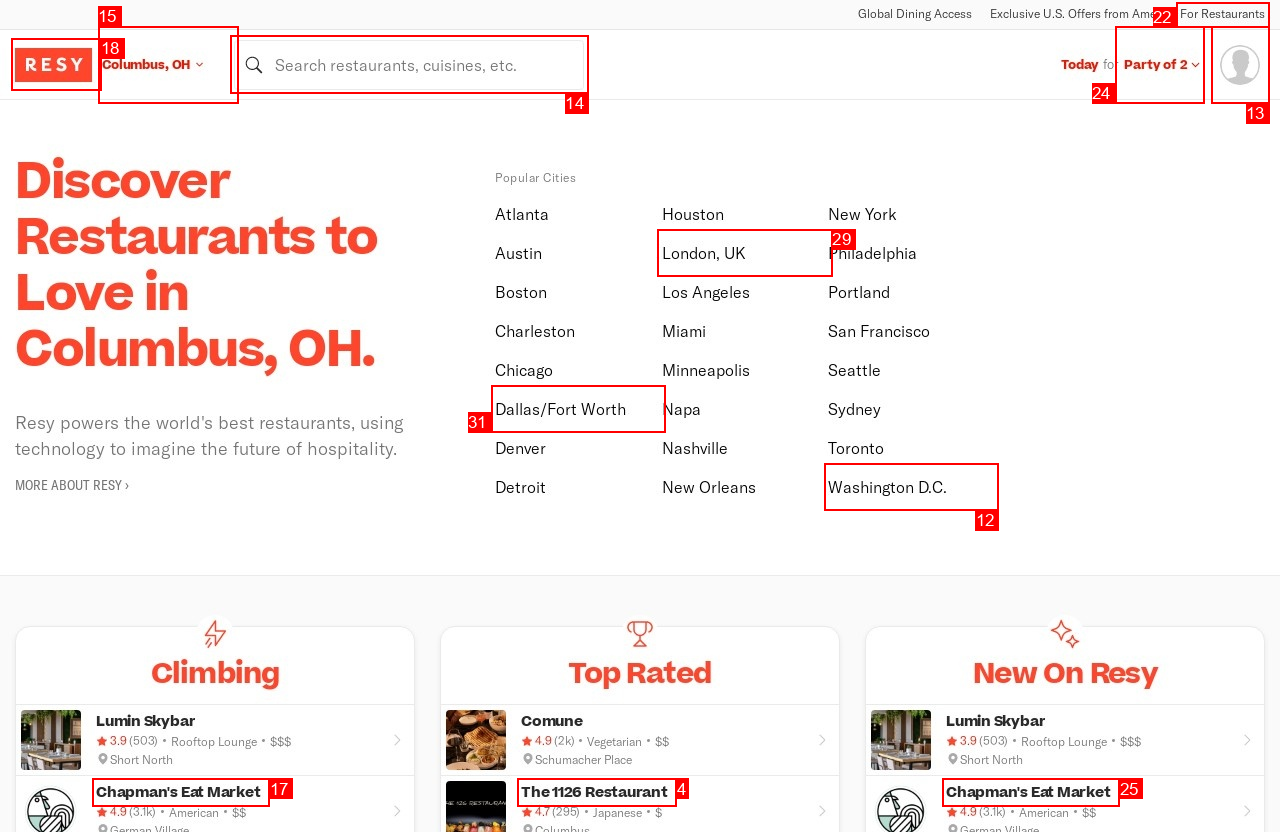


INPUT PROMPT (from dataset):
<image_start><image><image_end>
Imagine that you are imitating humans doing web navigation for a task step by step. At each stage, you can see the webpage like humans by a screenshot and know the previous actions before the current step decided by yourself through recorded history. You need to decide on the following action to take. You can click an element with the mouse, select an option, or type text with the keyboard. The output format should be a dictionary like: 
"{"ACTION": "CLICK" or "TYPE" or "SELECT", "MARK": a numeric id, e.g., 5, "VALUE": a string value for the action if applicable, otherwise None}".
You are asked to complete the following task: Find a Thai restaurant and get notified when they have an open table between 5 to 7 PM. For your convinience, I have labeled the candidates with numeric marks and bounding boxes on the screenshot. What is the next action you would take?



In [18]:
# Get sample from dataset
# sample = dataset[SAMPLE_INDEX]
# print("Conversations:", sample['conversations'])
# print("\nUser prompt:", sample['conversations'][0]['value'])
# print("\nGround truth:", sample['conversations'][1]['value'])

# image = sample['image'].convert('RGB')
# full_prompt = sample['conversations'][0]['value']  # Keep <image> tag
full_prompt = f"<image_start><image><image_end>\n{INSTRUCTION}"
# Display the image
print(f"\n{'='*60}")
print("INPUT IMAGE:")
print('='*60)
display(image)

print(f"\n{'='*60}")
print("INPUT PROMPT (from dataset):")
print('='*60)
print(full_prompt)

## 6. Run Inference

In [19]:
# Build conversation with the same format as training
# The prompt already has <image_start><image><image_end> from cell-13
convs = [
    {"role": "system", "content": "You are agent that can see, talk and act."},
    {"role": "user", "content": full_prompt},
]

formatted_prompt = processor.tokenizer.apply_chat_template(
    convs, tokenize=False, add_generation_prompt=True
)

# Run inference
inputs = processor(images=[image], texts=formatted_prompt, return_tensors="pt")
inputs['pixel_values'] = inputs['pixel_values'].unsqueeze(0)
inputs['image_sizes'] = inputs['image_sizes'].unsqueeze(0)
inputs = inputs.to('cuda')
inputs['pixel_values'] = inputs['pixel_values'].to(torch.bfloat16)

model.generation_config.pad_token_id = processor.tokenizer.pad_token_id

print("Running inference...")
with torch.inference_mode():
    output_ids = model.generate(
        **inputs,
        do_sample=False,
        num_beams=1,
        max_new_tokens=256,
        use_cache=False
    )

generate_ids = output_ids[:, inputs["input_ids"].shape[-1]:]
response = processor.decode(generate_ids[0], skip_special_tokens=True).strip()

print(f"\n{'='*60}")
print("MODEL RESPONSE:")
print('='*60)
print(response)

# Parse ground truth
ground_truth = json.loads(GROUND_TRUTH_BBOX)
print(f"\n{'='*60}")
print("GROUND TRUTH:", ground_truth)
print('='*60)

# Parse model response as JSON action
def parse_action(text):
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        json_match = re.search(r'\{.*\}', text, re.DOTALL)
        if json_match:
            try:
                return json.loads(json_match.group())
            except:
                pass
        return {"raw_response": text, "parse_error": True}

prediction = parse_action(response)

print(f"\n{'='*60}")
print("EVALUATION:")
print('='*60)

if prediction.get('parse_error'):
    print(f"PARSE ERROR - model did not output valid JSON")
    print(f"Raw response: {response}")
else:
    action_match = prediction.get('ACTION') == ground_truth.get('ACTION')
    element_match = str(prediction.get('MARK')) == str(ground_truth.get('MARK'))
    value_match = True
    if ground_truth.get('ACTION') == 'TYPE':
        value_match = prediction.get('VALUE') == ground_truth.get('VALUE')
    overall = action_match and element_match and value_match

    print(f"Prediction:       {prediction}")
    print(f"Action correct:   {action_match}  (pred={prediction.get('ACTION')}, gt={ground_truth.get('ACTION')})")
    print(f"Element correct:  {element_match}  (pred={prediction.get('MARK')}, gt={ground_truth.get('MARK')})")
    print(f"Value correct:    {value_match}  (pred={prediction.get('VALUE')}, gt={ground_truth.get('VALUE')})")
    print(f"Overall correct:  {overall}")

Running inference...

MODEL RESPONSE:
{"ACTION": "CLICK", "MARK": 9, "VALUE": "None"}

GROUND TRUTH: {'ACTION': 'TYPE', 'MARK': 14, 'VALUE': 'thai'}

EVALUATION:
Prediction:       {'ACTION': 'CLICK', 'MARK': 9, 'VALUE': 'None'}
Action correct:   False  (pred=CLICK, gt=TYPE)
Element correct:  False  (pred=9, gt=14)
Value correct:    False  (pred=None, gt=thai)
Overall correct:  False


## 7. Cleanup

In [ ]:
del model
torch.cuda.empty_cache()
print("Model deleted, GPU memory freed.")

Model deleted, GPU memory freed.


: 